# Day 1 — Sprint 2 Planning & Convolutional Neural Networks

## Overview

Introduced Sprint 2 planning and the fundamental concepts of Convolutional Neural Networks (CNNs). The session focused on understanding convolution, filters, feature maps, and why CNNs are effective for image data. A small sample of the Melanoma Skin Cancer dataset was used for the hands-on convolution experiment.


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf

### Connect Google Drive

Connected Google Drive to access the Melanoma Skin Cancer dataset stored in the user's Drive.


In [5]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
dataset_path = "/content/drive/MyDrive/Cancer_ Dataset"



### Inspect Training Classes

Inspected the training directory to identify the available classes in the Melanoma Skin Cancer dataset.


In [9]:
train_path = os.path.join(dataset_path, "train")

os.listdir(train_path)

['Malignant', 'Benign']

### Select a Sample of Images

Selected a small and balanced sample of 10 images from the training dataset, including 5 Benign and 5 Malignant images.

This sample is used for the convolution hands-on experiment and visualization.


In [10]:
benign_path = os.path.join(train_path, "Benign")
malignant_path = os.path.join(train_path, "Malignant")

benign_images = os.listdir(benign_path)
malignant_images = os.listdir(malignant_path)

print("Number of Benign images:", len(benign_images))
print("Number of Malignant images:", len(malignant_images))

Number of Benign images: 6289
Number of Malignant images: 5590


In [11]:
sample_images = []

# 5 Benign images
for filename in benign_images[:5]:
    path = os.path.join(benign_path, filename)
    image = Image.open(path).convert("RGB")
    sample_images.append(("Benign", filename, image))

# 5 Malignant images
for filename in malignant_images[:5]:
    path = os.path.join(malignant_path, filename)
    image = Image.open(path).convert("RGB")
    sample_images.append(("Malignant", filename, image))

print("Total sample images:", len(sample_images))

Total sample images: 10


### Visualize Sample Images

Visualized the selected sample images to inspect the appearance of both Benign and Malignant skin lesions before applying convolution.


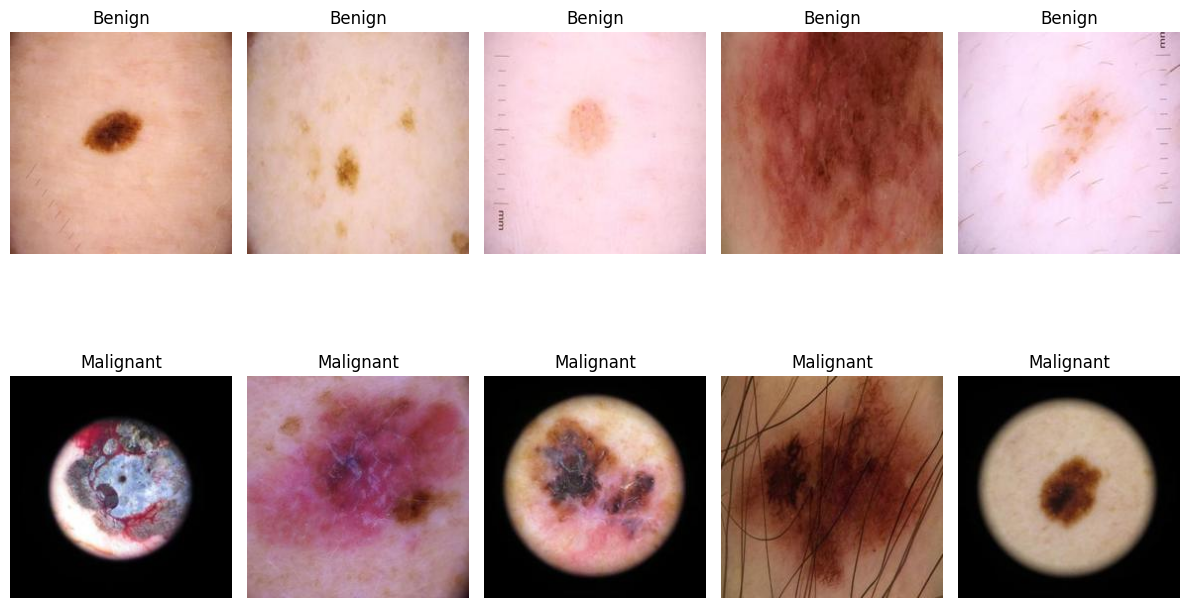

In [12]:
plt.figure(figsize=(12, 8))

for i, (label, filename, image) in enumerate(sample_images):
    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()


### Inspect Image Dimensions

Inspected the dimensions of the sample images to understand their original resolution before applying the convolution operation.


In [13]:
for label, filename, image in sample_images:
    print(f"{label}: {image.size}")

Benign: (224, 224)
Benign: (224, 224)
Benign: (224, 224)
Benign: (224, 224)
Benign: (224, 224)
Malignant: (224, 224)
Malignant: (224, 224)
Malignant: (224, 224)
Malignant: (224, 224)
Malignant: (224, 224)


### Convert Image to NumPy Array

Converted a sample image from a PIL image object into a NumPy array to represent the image as numerical pixel values.

The RGB image has three color channels: Red, Green, and Blue.


In [14]:
sample_image = np.array(sample_images[0][2])

print("Image shape:", sample_image.shape)
print("Data type:", sample_image.dtype)

Image shape: (224, 224, 3)
Data type: uint8


### Convert Image to Grayscale

Converted the RGB image to grayscale to simplify the convolution experiment.

A grayscale image contains a single intensity channel instead of three RGB channels, making the edge-detection operation easier to visualize and understand.


In [15]:
gray_image = Image.fromarray(sample_image).convert("L")
gray_array = np.array(gray_image)

print("Grayscale image shape:", gray_array.shape)

Grayscale image shape: (224, 224)


### Define an Edge Detection Filter

Defined a hand-crafted 3×3 convolution filter designed to detect vertical edges in the image.

The filter is applied across the image to identify areas where pixel intensity changes significantly from left to right.


In [16]:
edge_filter = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])

print("Edge detection filter:")
print(edge_filter)

Edge detection filter:
[[-1  0  1]
 [-1  0  1]
 [-1  0  1]]


In [17]:
# Convert image to float32
image_tensor = tf.convert_to_tensor(gray_array, dtype=tf.float32)

# Add batch and channel dimensions
image_tensor = image_tensor[tf.newaxis, ..., tf.newaxis]

# Convert filter to TensorFlow format
filter_tensor = tf.convert_to_tensor(
    edge_filter.reshape(3, 3, 1, 1),
    dtype=tf.float32
)

# Apply convolution
feature_map = tf.nn.conv2d(
    image_tensor,
    filter_tensor,
    strides=[1, 1, 1, 1],
    padding="SAME"
)

feature_map = feature_map[0, :, :, 0].numpy()

print("Feature map shape:", feature_map.shape)

Feature map shape: (224, 224)


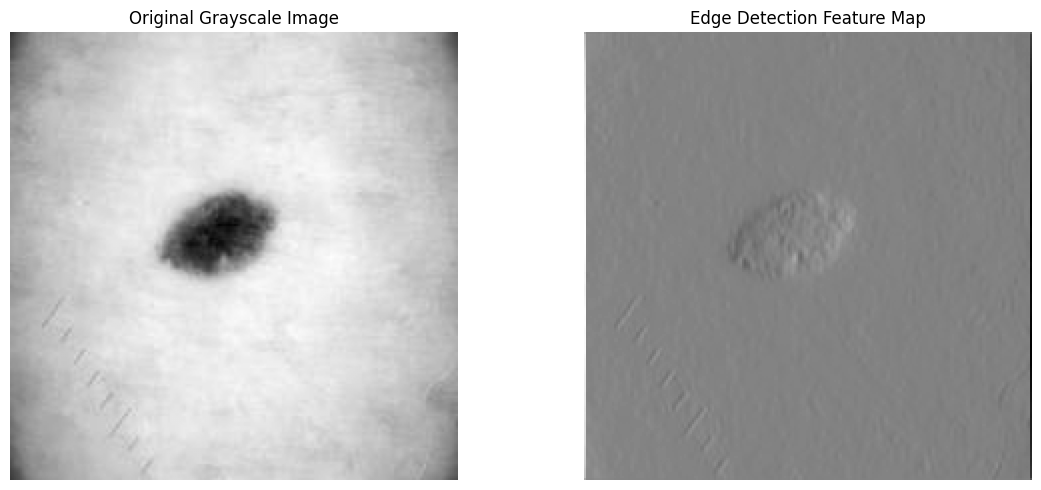

In [18]:
plt.figure(figsize=(12, 5))

# Original grayscale image
plt.subplot(1, 2, 1)
plt.imshow(gray_array, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")

# Feature map
plt.subplot(1, 2, 2)
plt.imshow(feature_map, cmap="gray")
plt.title("Edge Detection Feature Map")
plt.axis("off")

plt.tight_layout()
plt.show()

### Apply Convolution to Sample Images

Applied the same edge-detection filter to all 10 sample images to observe how convolution detects similar visual patterns across different images and locations.


In [19]:
feature_maps = []

for label, filename, image in sample_images:
    image_array = np.array(image.convert("L"), dtype=np.float32)

    image_tensor = tf.convert_to_tensor(
        image_array[tf.newaxis, ..., tf.newaxis]
    )

    feature_map_tensor = tf.nn.conv2d(
        image_tensor,
        filter_tensor,
        strides=[1, 1, 1, 1],
        padding="SAME"
    )

    feature_map = feature_map_tensor[0, :, :, 0].numpy()

    feature_maps.append((label, filename, feature_map))

print("Number of feature maps:", len(feature_maps))

Number of feature maps: 10


### Visualize Feature Maps

Visualized the feature maps generated from the same edge-detection filter across the 10 sample images to observe the detected patterns.


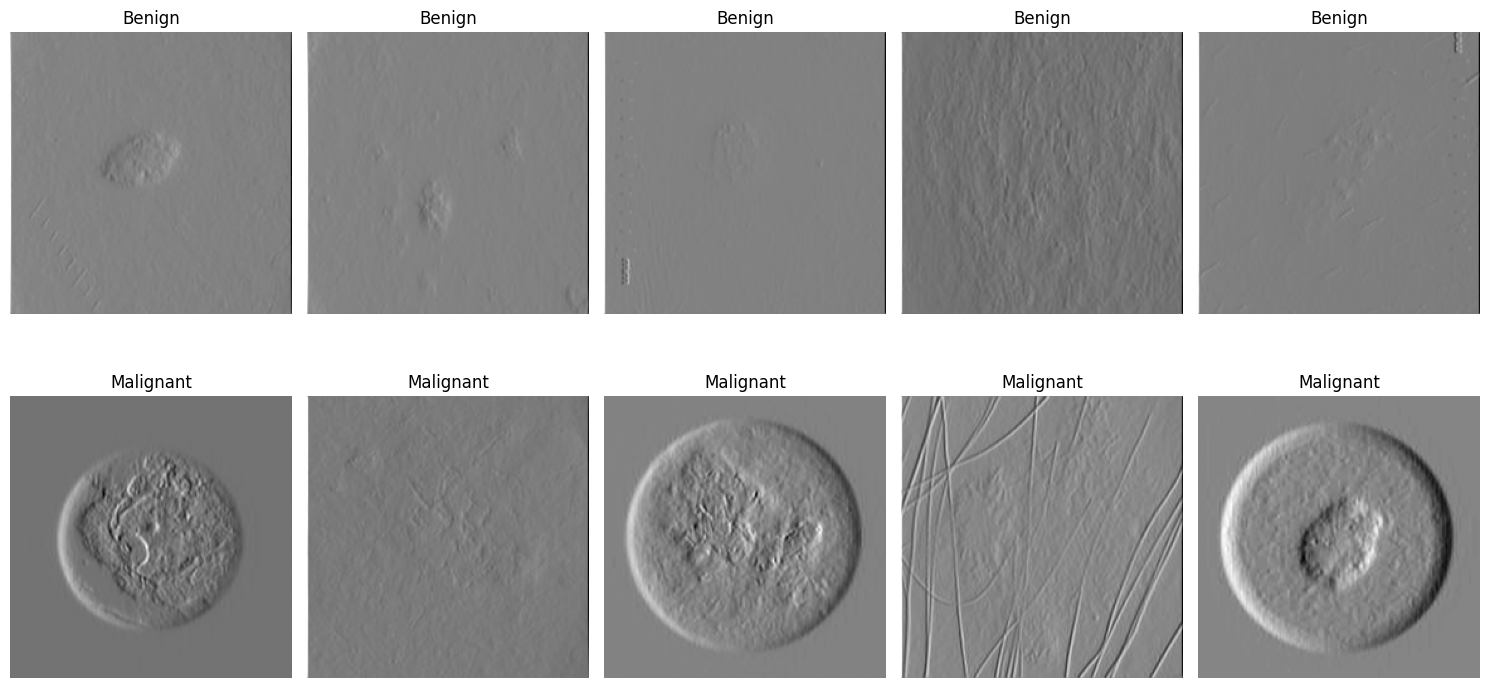

In [20]:
plt.figure(figsize=(15, 8))

for i, (label, filename, feature_map) in enumerate(feature_maps):
    plt.subplot(2, 5, i + 1)
    plt.imshow(feature_map, cmap="gray")
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()

##  Parameter Sharing

CNNs use the same convolutional filter across different regions of an image. This means the same set of learnable weights is reused at every spatial location.

For example, a 3×3 filter contains only 9 weights (plus a bias), and these weights are applied across the entire image.

In contrast, a Dense layer connects every input pixel to every neuron, resulting in a very large number of parameters.

Parameter sharing makes CNNs much more efficient and allows the same visual pattern, such as an edge or texture, to be detected regardless of its location in the image.


### Dense Network vs. CNN

| Aspect            | Dense Network                | CNN                          |
| ----------------- | ---------------------------- | ---------------------------- |
| Connections       | Fully connected              | Local connections            |
| Parameters        | Very large for images        | Much fewer                   |
| Spatial structure | Mostly lost after flattening | Preserved                    |
| Pattern detection | Position-dependent           | Same filter across locations |
| Weight sharing    | No                           | Yes                          |


##  Translation Invariance

CNNs can detect the same visual pattern at different locations in an image because the same convolutional filter is applied across the entire image.

This allows a pattern, such as an edge or texture, to be detected even when its position changes.



## Feature Hierarchy

CNNs learn visual features progressively through different layers.

Early layers learn simple patterns such as edges and lines. Middle layers combine these patterns to detect shapes and textures, while deeper layers learn more complex features related to objects and structures.

This hierarchical feature learning allows CNNs to automatically learn useful representations directly from image data.
